In [322]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', '*', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

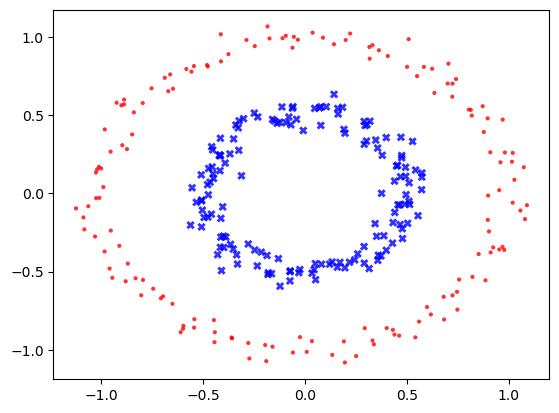

In [323]:
from sklearn.datasets import make_moons, make_circles

X, y = make_circles(
    n_samples=300,
    factor=0.5,   # raggio del cerchio interno
    noise=0.05,
    random_state=1
)
markers=['.', 'X']
colors = ['r', 'b']

for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='none')

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [325]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 0.4444444444444444


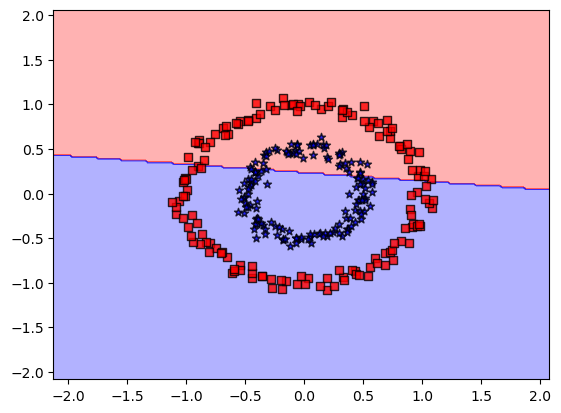

In [326]:
plot_decision_regions(X, y, linear_svm)

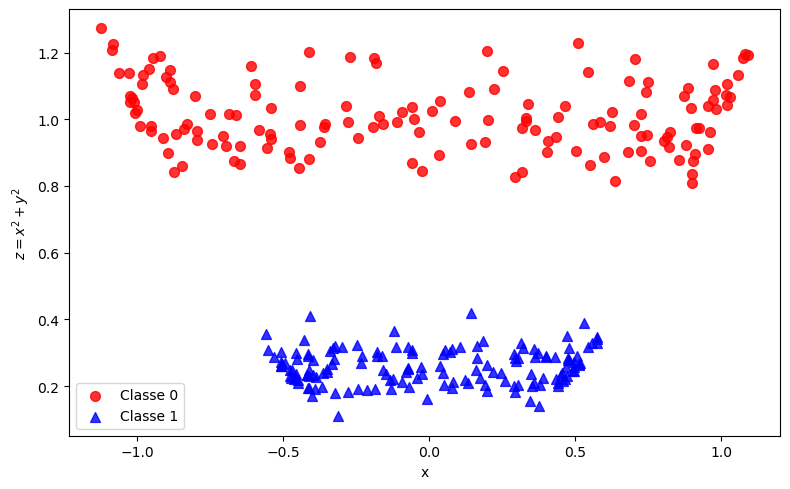

In [327]:
x1 = X[:, 0]
x2 = X[:, 1]

z = x1**2+x2**2 #nuova feature

X_3d = np.c_[x1, x2, z] #dataset tridimensionale

markers = ['o', '^']
colors = ['red', 'blue']

# Plot 3D
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

for idx, cl in enumerate(np.unique(y)):
    ax.scatter(
        X_3d[y == cl, 0], # scelgo la x
        X_3d[y == cl, 2], # a l'asse z
        c=colors[idx],
        marker=markers[idx],
        s=50,
        alpha=0.8,
        label=f'Classe {cl}'
    )

# Etichette
ax.set_xlabel('x')

ax.set_ylabel(r'$z = x^2 + y^2$')

# Angolo di visualizzazione

ax.legend()
plt.tight_layout()
plt.show()

il seguenti piano è costruito a partire delle coordinate x e z, possiamo osservare che così facendo risulta esplicità la separabilità dei punti

In [328]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y, test_size=0.3, random_state=1
)

In [329]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 1.0


**vantaggio**: Le trasformazioni in spazi ad alta dimensionalità consentono di rendere i dati più facilmente separabili, migliorando così le prestazioni dei modelli di classificazione. 

**problema**: Tuttavia, lavorare esplicitamente in questi spazi può essere molto costoso dal punto di vista computazionale, *soprattutto quando il numero di feature è elevato o quando si considerano trasformazioni polinomiali di grado alto.*

**kernel trick**: risolve questo problema evitando di calcolare esplicitamente la trasformazione $\phi(x)$, che mappa i dati dallo spazio originale a uno spazio di dimensione più alta $\mathcal{H}$.

**funzione kernel $K$** permette di calcolare **direttamente, nello spazio di partenza, il prodotto scalare tra le immagini di due vettori nello spazio trasformato**:

$$
K(x_1, x_2) = \phi(x_1) \cdot \phi(x_2)
$$

**perche' funziona**? Il principio alla base del kernel trick è che molti algoritmi di machine learning, come le Support Vector Machines (SVM), possono essere **formulati utilizzando esclusivamente prodotti scalari tra vettori**. 

**conclusione**: invece di calcolare direttamente il prodotto scalare $\phi(x_1) \cdot \phi(x_2)$, è possibile sostituirlo con $K(x_1, x_2)$, ottenendo il corrispondente prodotto scalare nello spazio $\mathcal{H}$.

In questo modo si sfruttano i vantaggi delle trasformazioni in spazi ad alta dimensionalità senza dover eseguire esplicitamente i calcoli in tali spazi, con un notevole risparmio computazionale.

**che kernel uso?** Un kernel molto diffuso è il kernel gaussiano o Radial Basis Function (RBF), definito come

$$
K(x_1, x_2) =e^{\left(-\gamma \|x_1 - x_2\|^2\right)}
$$

dove $\gamma > 0$ controlla l'influenza dei singoli punti di addestramento: 
* **cosa fa?** *modera il problema dell'overfitting dovuto all'eccessivo aumento delle dimensioni nella proiezione*.
* tanto più gamma sarà grande tanto più si da enfasi alle singole distanze tra i campioni, ossia il margine si adatta di piu ai campioni
* **al diminuire di gamma**: il margine si allarga.

**$K$ espande su un numero potenzialmente infinito di dimensioni**: questa funzione può essere espansa tramite lo sviluppo in serie dell’esponenziale:

$$
e^t = \sum_{n=0}^{\infty} \frac{t^n}{n!}
$$

- prodotto scalare di un numero infinito di termini all'interno di uno spazio infinito.


Applicandolo al kernel, si ottiene una combinazione infinita di termini polinomiali. Overo, i dati vengono proiettati in uno spazio di dimensione potenzialmente infinita. Questo è particolarmente efficace quando la relazione tra le variabili è complessa e non lineare.

**Esempi**: 
* `gamma=0.1`: allora l'area e' molto sghemba e morbida
* `gamma=1`: funziona bene
* `gamma=20`: piu stretta sugli esempi.

In [330]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

rbf_svm = SVC(kernel='rbf', gamma=0.1)
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 0.7777777777777778


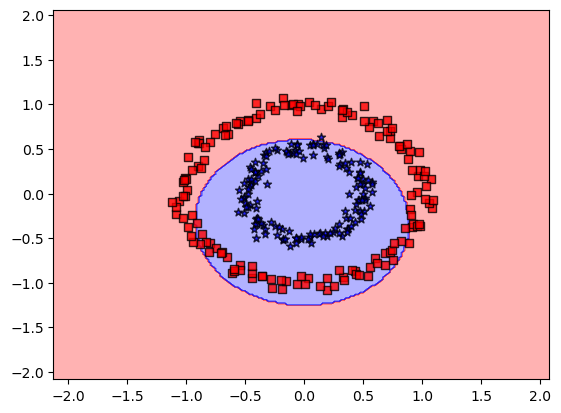

In [331]:
plot_decision_regions(X, y, rbf_svm)

# Valutare un modello


![bias](18_01.png)

* **bias elevato**: modello troppo semplice, non legato al caso. non abbastanza preciso da catturare la complessita del dataset
* **varianza**: indica overfitting, ossia un modello troppo legato alle caratteristiche del training set, più addestramenti (su training set diversi) portano a diversi modelli con prestazioni diverse. 

* * ad ogni possibile fitting avrei un modello che è adatto unicamente a quel particolare training set e i valori di accuracy dei vari fitting saranno piuttosto eterogenei(**ed ecco perchè si dice alta varianza**). 

**regolarizzazione**: ad esempio la *L2* ($\gamma||w||^2/2$), si penalizzano valori estremi e si riduce la varianza.

In [332]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [333]:
# ==========================================================
# 1. Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=300, # 1000
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    flip_y=0.10,       # 10% di rumore, inverto alcuni valori
    class_sep=0.8,
    random_state=1
)

In [334]:
#esempio di alta varianza (overfitting)
accuracies = []
# ==========================================================
# Proviamo diversi random_state
# ==========================================================
for seed in range(10):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        stratify=y,
        random_state=seed
    )

    # Modello SVM
    model = SVC(
        kernel='rbf',
        # C ontrolla il compromesso tra margine ed errore di classificazione
        C = 0.5, # 1
        gamma = 0.1 # 0.5
    )

    # Training
    model.fit(X_train, y_train)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = np.mean(y_test==y_test_pred)

    accuracies.append(test_acc)
    print( f"Test Accuracy = {test_acc:.4f}")

print(f"Accuracies variance = {np.var(np.array(accuracies))}")


Test Accuracy = 0.7333
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7556
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7111
Accuracies variance = 0.0020740740740740732


# Problema: overfitting sul test set
**obiettivo**: Dobbiamo scegliere dei valori migliori per $C, \gamma$.

**problema**: se provassi a cambiarli in base alla performance sul test set $T$, ogni volta, fino a che non ottengo una buona performance, allora **starei facendo overfitting sul test set**

**perche**? scelgo i parametri, poi addestro su $T$, riescelgo i parametri, poi addestro su $T$... sto ottimizzando i parametri solo su $T$.

**soluzione**: devo dividere in piu insiemi i dati!
* **test**: faccio lo split dei dati, con il resto creo il validation e il training. E' l'ultimo set su cui verifico il modello dopo aver aggiustato i parametri sul validation.
* **validation**
* **training**


### Metodo holdout
**obiettivo**: idealmente vorremmo stimare degli iperparametri ($C$, $\gamma$ ecc $\dots$) che riescano ad abbassare la **varianza del modello** entro un certo **tasso di tollerabilità** per questo è usato il metodo holdout.

Si usano training set e validation set per scegliere gli iperparametri, infine il test set per la verifica finale. 


**vantaggio**: è estremamente veloce perché richiede di addestrare il modello una sola volta per ogni combinazione di iperparametri. 

**svantaggio**: è che il risultato dipende molto da come il caso ha "tagliato" il dataset all'inizio: *se nel Validation Set finiscono per caso tutti gli esempi facili (o tutti quelli difficili), la stima di $C$ e $\gamma$ sarà sbilanciata.* Per ovviare a questo, si usa una sua evoluzione chiamata K-Fold Cross-Validation.

In [335]:
# ==========================================================
# Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=2,
    flip_y=0.05,       # 5% di etichette errate
    class_sep=1.0,
    random_state=1
)


In [336]:
# Test set = 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=0
)

# Validation set = 15% del totale
# X_temp = 85% del totale -> 15/85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=0
)

print("Training set   :", len(X_train))
print("Validation set :", len(X_val))
print("Test set       :", len(X_test))

Training set   : 1050
Validation set : 225
Test set       : 225


In [337]:
# ==========================================================
# MODELLO 1
# ==========================================================
model1 = SVC(
    kernel='rbf',
    C=1,
    gamma=1.5,
    random_state=1
)

model1.fit(X_train, y_train)

# Accuracy sul training set
train_pred_1 = model1.predict(X_train)
train_acc_1 = np.mean(y_train == train_pred_1)

# Accuracy sul validation set
val_pred_1 = model1.predict(X_val)
val_acc_1 =  np.mean(y_val == val_pred_1)

print("\nMODELLO 1 (alta varianza)")
print(f"Training accuracy   : {train_acc_1:.4f}")
print(f"Validation accuracy : {val_acc_1:.4f}")


MODELLO 1 (alta varianza)
Training accuracy   : 1.0000
Validation accuracy : 0.5022


In [338]:
# ==========================================================
# MODELLO 2
# ==========================================================
model2 = SVC(
    kernel='rbf',
    C=0.5,
    gamma=0.01,
    random_state=1
)

model2.fit(X_train, y_train)

# Accuracy sul training set
train_pred_2 = model2.predict(X_train)
train_acc_2 = np.mean(y_train==train_pred_2)

# Accuracy sul validation set
val_pred_2 = model2.predict(X_val)
val_acc_2 = np.mean(y_val==val_pred_2)

print("\nMODELLO 2 (varianza ridotta)")
print(f"Training accuracy   : {train_acc_2:.4f}")
print(f"Validation accuracy : {val_acc_2:.4f}")



MODELLO 2 (varianza ridotta)
Training accuracy   : 0.9114
Validation accuracy : 0.9067


In [339]:
# ==========================================================
# Scelta del modello migliore
# ==========================================================
if val_acc_2 > val_acc_1:
    best_model = model2
    print("\nIl Modello 2 è migliore sul validation set.")
else:
    best_model = model1
    print("\nIl Modello 1 è migliore sul validation set.")



Il Modello 2 è migliore sul validation set.


In [340]:
# ==========================================================
# Riaddestramento finale su Train + Validation
# ==========================================================
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.hstack([y_train, y_val])

best_model.fit(X_train_final, y_train_final)

# ==========================================================
# Valutazione finale sul Test Set
# ==========================================================
y_test_pred = best_model.predict(X_test)
test_acc = np.mean(y_test==y_test_pred)

print(f"\nAccuracy finale sul Test Set: {test_acc:.4f}")


Accuracy finale sul Test Set: 0.8800


## Convalida incrociata (cross validation)
il modello viene addestrato più volte usando delle porzioni del dataset iniziale.


- **Suddivisione in fold**: Il dataset viene diviso in $k$ sottoinsiemi (chiamati fold) della stessa dimensione. Valori tipici per $k$ sono 5 o 10.
- **Iterazione**: Il processo di addestramento e valutazione viene ripetuto $k$ volte.
- Il meccanismo Train/Validation: In ogni singola iterazione $i$ (da 1 a $k$):
* * Il fold $i$-esimo viene isolato e usato come Validation Set.
* * I restanti $k-1$ fold vengono concatenati e usati tutti insieme come Training Set.
* * Il modello viene addestrato da zero su questi $k-1$ fold e le sue previsioni vengono valutate sull'unico fold isolato, producendo un punteggio (es. accuratezza, MSE).
- **Media dei risultati**: Alla fine delle $k$ iterazioni, avrai $k$ punteggi distinti. La stima finale delle prestazioni del modello è calcolata come la media aritmetica di questi $k$ punteggi.


questo avvine per testare più combinazioni di iperparametri e per avere un modello più rubbusto

In [341]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1) #crea suddivisioni dei fold 

X = range(12)
y = [0,1,1,1,0,1,1,1,0,0,1,0]

# divide in indici per il training e per la validation
for train_idx, val_idx in kf.split(X, y):
    print(train_idx, val_idx)

[ 0  1  2  3  5  7  8 10 11] [4 6 9]
[ 2  3  4  5  6  7  8  9 11] [ 0  1 10]
[ 0  1  2  3  4  6  8  9 10] [ 5  7 11]
[ 0  1  4  5  6  7  9 10 11] [2 3 8]


In [342]:
# ==========================================================
# 1. Dataset sintetico
# ==========================================================
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=2,
    flip_y=0.08,
    class_sep=0.9,
    random_state=1
)

In [343]:
# ==========================================================
# K-Fold Cross Validation
# ==========================================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)


In [344]:
# ==========================================================
# HOLD OUT DEL TEST SET (mai toccato)
# ==========================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=1
)

In [ ]:
# vecchi iperparametri
C_values = [0.1, 1, 10, 12, 15, 17]
gamma_values = [0.001,0.01,0.1]

best_score = 0
best_params = None

In [ ]:
# ==========================================================
# Iperparametri da testare, una volta identificato che gamma 0.01 e' il migliore probabilmente
# ==========================================================
C_values = [0.1, 1, 10, 12, 15, 17]
gamma_values = [#0.001,
    0.01,
    #0.1
    ]

best_score = 0
best_params = None

In [346]:
# ==========================================================
# Loop sugli iperparametri
# ==========================================================

# i parametri su cui itero sono prefissati!
for C in C_values:
    for gamma in gamma_values:

        fold_scores = []

        # ======================================================
        # Cross-validation
        # ======================================================
        for train_idx, val_idx in kf.split(X_train_full, y_train_full):

            X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
            y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

            model = SVC(kernel="rbf", C=C, gamma=gamma)

            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            acc = np.mean(y_val==preds)
            fold_scores.append(acc)

        mean_score = np.mean(fold_scores)

        print(f"C={C:<3} gamma={gamma:<5} -> CV accuracy = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = (C, gamma)


C=0.1 gamma=0.01  -> CV accuracy = 0.8424
C=1   gamma=0.01  -> CV accuracy = 0.8682
C=10  gamma=0.01  -> CV accuracy = 0.8729
C=12  gamma=0.01  -> CV accuracy = 0.8729
C=15  gamma=0.01  -> CV accuracy = 0.8671
C=17  gamma=0.01  -> CV accuracy = 0.8659


attenzione la cella sovrastante ci mostra che se osservo che a pari valori di C ma per valori via via sempre più piccoli di gamma la mia accuracy cresce nulla vieta di poter avere una validazione per più valori di gamma. e stessa cosa vale viceversa per valori fissi di gamma e via via più grandi di C

## attenzione
una volta trovati i "migliori gamma e C", mi conviene andare avanti?
* dipende dai miei parametri, magari ci sono altre cose da vedere.

In [347]:

# ==========================================================
# Migliori iperparametri
# ==========================================================
print("\nMigliori iperparametri trovati:")
print("C =", best_params[0], "gamma =", best_params[1])
print("CV accuracy media =", best_score)



Migliori iperparametri trovati:
C = 10 gamma = 0.01
CV accuracy media = 0.8729411764705881


In [348]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVC(
    kernel="rbf",
    C=best_params[0],
    gamma=best_params[1]
)

final_model.fit(X_train_full, y_train_full)

print("\nModello finale addestrato su tutto il dataset.")


Modello finale addestrato su tutto il dataset.


In [349]:
# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)

print("\nMigliori parametri:", best_params)
print("Test accuracy finale:", test_acc)


Migliori parametri: (10, 0.01)
Test accuracy finale: 0.8466666666666667


## Matrice di confusione

dopo aver addestrato un modello la matrice di confusione fornisce qualche dato in più sulle prestazioni del modello su un insieme di test.
di seguito abbiamo un esempio con 2 classi.(riquadri in giallo sono gli elementi classificati correttamente)

In [350]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[65  7]
 [16 62]]


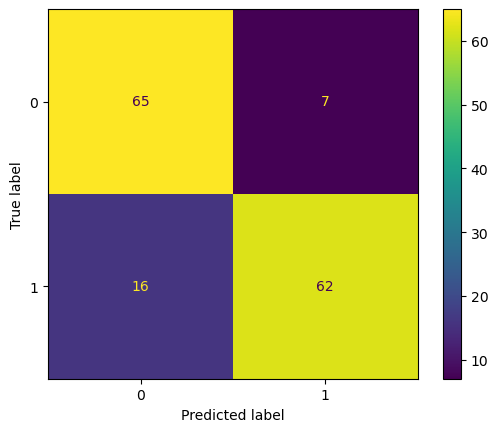

In [351]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [352]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(tn, fp, fn, tp)

65 7 16 62


In [353]:
#queste metriche sono errori di diverse tipologie per un modello e a volte il loro uso permette una valutazione più dettagliata
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi 
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: 0.8985507246376812
Recall: 0.7948717948717948
